In [21]:
# NOTE: If qiskit is not installed, uncomment and run the following line:
# !pip install qiskit qiskit-aer

import numpy as np
import matplotlib.pyplot as plt

try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    from qiskit.quantum_info import Statevector
    from qiskit.circuit.library import QFT
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Qiskit or qiskit-aer is not installed. Please install it using: pip install qiskit qiskit-aer") from e

from numpy import pi, sin, cos, sqrt, exp, real, imag

# Parameters
nx = ny = nz = 5  # 2^3 = 8 points in each direction
N = 2 ** nx
L = 2 * pi
x = np.linspace(0, L, N, endpoint=False)
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')

# Taylor-Green vortex velocity field (u,v,w)
ux = sin(X) * cos(Y) * cos(Z)
uy = -cos(X) * sin(Y) * cos(Z)
uz = np.zeros_like(X)

# Construct a simple spinor wavefunction from ux, uy (uz=0)
# Use phase encoding strategy
phi = np.arctan2(uy, ux)
rho = ux**2 + uy**2 + 1e-6  # avoid zero
amp = np.sqrt(rho)

# Two spinor components
psi_plus = amp * np.exp(1j * phi)
psi_minus = amp * np.exp(-1j * phi)

# Normalize and flatten state
psi_plus = psi_plus.reshape(-1)
psi_minus = psi_minus.reshape(-1)
psi_full = np.concatenate([psi_plus, psi_minus])
psi_full = psi_full / np.linalg.norm(psi_full)

# Number of qubits: nx+ny+nz for spatial + 1 for spin
qnum = nx + ny + nz + 1

# Build evolution circuit
qc = QuantumCircuit(qnum)
qc.initialize(psi_full)
qc.barrier()

# QFT layers
def apply_qft_block(circ, q_start, nq):
    qft = QFT(nq).decompose()
    circ.append(qft, list(range(q_start, q_start + nq)))
    return circ

apply_qft_block(qc, 0, nx)
apply_qft_block(qc, nx, ny)
apply_qft_block(qc, nx + ny, nz)
qc.barrier()

# Placeholder kinetic operator (free evolution)
def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.rz(2**i * dt, i)
    return qc



In [22]:
dt = 1.0
qc.append(kinetic_operator(nx, dt), list(range(0, nx)))
qc.append(kinetic_operator(ny, dt), list(range(nx, nx+ny)))
qc.append(kinetic_operator(nz, dt), list(range(nx+ny, nx+ny+nz)))
qc.barrier()

# Inverse QFT layers (fix: explicitly apply inverse QFT gates)
qft_x_inv = QFT(nx, do_swaps=False).inverse().decompose()
qft_y_inv = QFT(ny, do_swaps=False).inverse().decompose()
qft_z_inv = QFT(nz, do_swaps=False).inverse().decompose()

qc.append(qft_x_inv, list(range(0, nx)))
qc.append(qft_y_inv, list(range(nx, nx + ny)))
qc.append(qft_z_inv, list(range(nx + ny, nx + ny + nz)))
qc.barrier()



CircuitInstruction(operation=Instruction(name='barrier', num_qubits=16, num_clbits=0, params=[]), qubits=(<Qubit register=(16, "q"), index=0>, <Qubit register=(16, "q"), index=1>, <Qubit register=(16, "q"), index=2>, <Qubit register=(16, "q"), index=3>, <Qubit register=(16, "q"), index=4>, <Qubit register=(16, "q"), index=5>, <Qubit register=(16, "q"), index=6>, <Qubit register=(16, "q"), index=7>, <Qubit register=(16, "q"), index=8>, <Qubit register=(16, "q"), index=9>, <Qubit register=(16, "q"), index=10>, <Qubit register=(16, "q"), index=11>, <Qubit register=(16, "q"), index=12>, <Qubit register=(16, "q"), index=13>, <Qubit register=(16, "q"), index=14>, <Qubit register=(16, "q"), index=15>), clbits=())

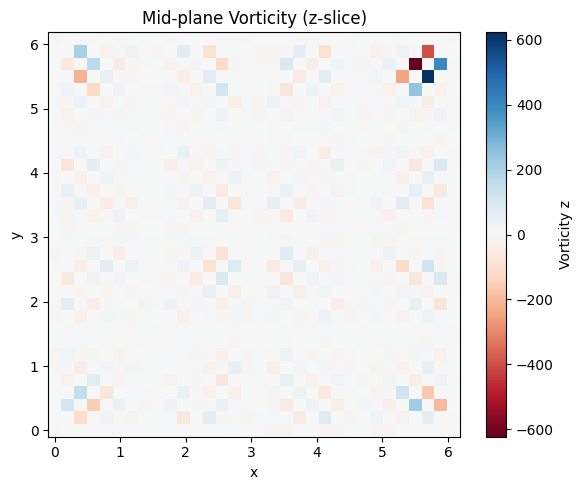

In [23]:
# Run the circuit
qc.save_statevector()  # ✅ 显式保存量子态
sim = AerSimulator(method='statevector')
qc = transpile(qc, sim)
result = sim.run(qc).result()
final_state = result.data(0)['statevector']


# Reshape state into spinor field
psi_out = np.array(final_state.data)
psi_out = psi_out.reshape(2, N, N, N)  # [spin, x, y, z]
psi_p = psi_out[0]
psi_m = psi_out[1]

# Compute velocity field from wavefunction
kx = ky = kz = np.fft.fftfreq(N, d=L/N) * N
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

def gradient_fft(f):
    f_k = np.fft.fftn(f)
    dfx = np.fft.ifftn(1j * KX * f_k)
    dfy = np.fft.ifftn(1j * KY * f_k)
    dfz = np.fft.ifftn(1j * KZ * f_k)
    return dfx, dfy, dfz

dpsi_p_x, dpsi_p_y, dpsi_p_z = gradient_fft(psi_p)
dpsi_m_x, dpsi_m_y, dpsi_m_z = gradient_fft(psi_m)

rho = np.abs(psi_p)**2 + np.abs(psi_m)**2
ux = real(psi_p.conj()*dpsi_p_x + psi_m.conj()*dpsi_m_x).real / rho
uy = real(psi_p.conj()*dpsi_p_y + psi_m.conj()*dpsi_m_y).real / rho
uz = real(psi_p.conj()*dpsi_p_z + psi_m.conj()*dpsi_m_z).real / rho

# Compute vorticity
vor_x = np.gradient(uz, axis=1) - np.gradient(uy, axis=2)
vor_y = np.gradient(ux, axis=2) - np.gradient(uz, axis=0)
vor_z = np.gradient(uy, axis=0) - np.gradient(ux, axis=1)

# Plot z-slice
plt.figure(figsize=(6,5))
plt.pcolormesh(x, x, vor_z[:,:,N//2], shading='auto', cmap='RdBu')
plt.colorbar(label='Vorticity z')
plt.title("Mid-plane Vorticity (z-slice)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


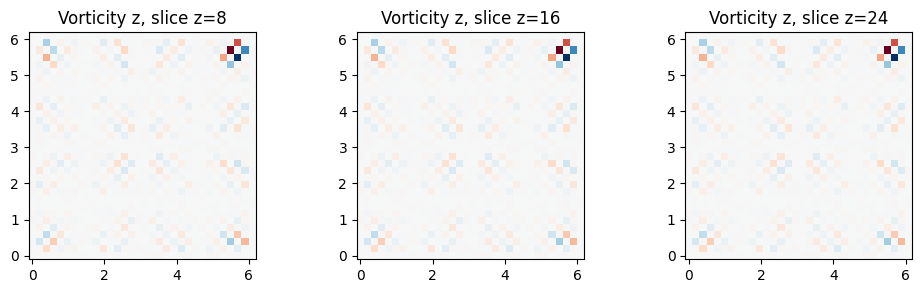

In [24]:
# 多层切片显示 z 平面涡度
fig = plt.figure(figsize=(10, 3))
for i, zi in enumerate([N//4, N//2, 3*N//4]):
    ax = fig.add_subplot(1, 3, i+1)
    ax.pcolormesh(x, x, vor_z[:, :, zi], shading='auto', cmap='RdBu')
    ax.set_title(f"Vorticity z, slice z={zi}")
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()
